# Load the dataset

In [1]:
import pandas as pd
train_df = pd.read_csv(r"D:\THE CAPSULE BOOK\PROJECTS_BOOK\urban_land_cover_prediction\urban+land+cover\urban+land+cover\training.csv")

In [2]:
train_df.head()

,class,BrdIndx,Area,Round,Bright,Compact,ShpIndx,Mean_NIR,Mean_R,Mean_G,...,SD_G_140,LW_140,GLCM1_140,Rect_140,GLCM2_140,Dens_140,Assym_140,NDVI_140,BordLngth_140,GLCM3_140
0,car,1.27,91,0.97,231.38,1.39,1.47,207.92,241.74,244.48,...,26.18,2.00,0.50,0.85,6.29,1.67,0.70,-0.08,56,3806.36
1,concrete,2.36,241,1.56,216.15,2.46,2.51,187.85,229.39,231.20,...,22.29,2.25,0.79,0.55,8.42,1.38,0.81,-0.09,1746,1450.14
2,concrete,2.12,266,1.47,232.18,2.07,2.21,206.54,244.22,245.79,...,15.59,2.19,0.76,0.74,7.24,1.68,0.81,-0.07,566,1094.04
3,concrete,2.42,399,1.28,230.40,2.49,2.73,204.60,243.27,243.32,...,13.51,3.34,0.82,0.74,7.44,1.36,0.92,-0.09,1178,1125.38
4,concrete,2.15,944,1.73,193.18,2.28,4.10,165.98,205.55,208.00,...,15.65,50.08,0.85,0.49,8.15,0.23,1.00,-0.08,6232,1146.38


In [3]:
train_df.shape

(168, 148)

In [4]:
train_df.isnull().any().sum()
# No missing values

np.int64(0)

In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Columns: 148 entries, class to GLCM3_140
dtypes: float64(133), int64(14), str(1)
memory usage: 195.5 KB


In [6]:
train_df.select_dtypes("int").columns

Index(['Area', 'BordLngth', 'Area_40', 'BordLngth_40', 'Area_60',
       'BordLngth_60', 'Area_80', 'BordLngth_80', 'Area_100', 'BordLngth_100',
       'Area_120', 'BordLngth_120', 'Area_140', 'BordLngth_140'],
      dtype='str')

In [7]:
train_df.select_dtypes("float").columns

Index(['BrdIndx', 'Round', 'Bright', 'Compact', 'ShpIndx', 'Mean_NIR',
       'Mean_R', 'Mean_G', 'SD_NIR', 'SD_R',
       ...
       'SD_R_140', 'SD_G_140', 'LW_140', 'GLCM1_140', 'Rect_140', 'GLCM2_140',
       'Dens_140', 'Assym_140', 'NDVI_140', 'GLCM3_140'],
      dtype='str', length=133)

In [8]:
train_df.select_dtypes("str").columns

Index(['class'], dtype='str')

All columns are numeric..Only the target variable is categorical

Checking the sparsity of the dataset

In [9]:
# Check sparsity

# Count zero values per column
zero_counts = (train_df == 0).sum()

# Filter columns with at least 1 zero
zero_counts = zero_counts[zero_counts > 0]

print(zero_counts)

NDVI        2
NDVI_40     1
NDVI_60     2
NDVI_80     2
NDVI_100    3
NDVI_120    3
NDVI_140    3
dtype: int64


Target variable class distribution

In [10]:
train_df["class"].value_counts(normalize=True)*100

class
grass        17.261905
building     14.880952
concrete     13.690476
tree         10.119048
shadow        9.523810
car           8.928571
pool          8.928571
asphalt       8.333333
soil          8.333333
Name: proportion, dtype: float64

## Dummy Classifier

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.dummy import DummyClassifier
import numpy as np

# X = features dataframe
X = train_df.drop(columns=["class"])
y = train_df["class"]
# y = target variable


# Label encoding the target variable
le = LabelEncoder()
y = le.fit_transform(y)


# Create pipeline
pipeline = Pipeline([
    ("model", DummyClassifier(strategy="stratified"))
])

# Define K-Fold
kf = StratifiedKFold(
    n_splits=5,     # k =5  folds
    shuffle=True,
    random_state=42
)

# Perform cross validation
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted"    # or 'neg_mean_squared_error'
)

print("F1-weighted scores for each fold:", scores)
print("Mean F1-weighted:", np.mean(scores))


F1-weighted scores for each fold: [0.0973262  0.07486631 0.24711824 0.12741703 0.11964565]
Mean F1-weighted: 0.13327468728538247


## Logistic Regression

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
import numpy as np

# X = features dataframe
X = train_df.drop(columns=["class"])
y = train_df["class"]
# y = target variable


# Label encoding the target variable
le = LabelEncoder()
y = le.fit_transform(y)


# Create pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=200))
])

# Define K-Fold
kf = StratifiedKFold(
    n_splits=5,     # k =5  folds
    shuffle=True,
    random_state=42
)

# Perform cross validation
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted"     # or 'neg_mean_squared_error'
)

print("F1-weighted scores for each fold:", scores)
print("Mean F1-weighted:", np.mean(scores))


F1-weighted scores for each fold: [0.8232684  0.81517698 0.79045921 0.7249836  0.70353535]
Mean F1-weighted: 0.7714847095863139


## LDA

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np

# X = features dataframe
X = train_df.drop(columns=["class"])
y = train_df["class"]
# y = target variable


# Label encoding the target variable
le = LabelEncoder()
y = le.fit_transform(y)


# Create pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearDiscriminantAnalysis())
])

# Define K-Fold
kf = StratifiedKFold(
    n_splits=5,     # k =5  folds
    shuffle=True,
    random_state=42
)

# Perform cross validation
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted"     # or 'neg_mean_squared_error'
)

print("F1-weighted scores for each fold:", scores)
print("Mean F1-weighted:", np.mean(scores))


F1-weighted scores for each fold: [0.25809991 0.49421102 0.36780132 0.39074074 0.44714679]
Mean F1-weighted: 0.3915999548085109


## Naive Bayes

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
import numpy as np

X = train_df.drop(columns=["class"])
y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

pipeline = Pipeline([
    ("model", GaussianNB())
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted"
)

print("F1-weighted scores:", scores)
print("Mean:", np.mean(scores))

F1-weighted scores: [0.76163738 0.65455819 0.88300376 0.75555556 0.78476338]
Mean: 0.7679036540801245


## LinearSVC

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
import numpy as np

X = train_df.drop(columns=["class"])
y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVC(max_iter=5000,random_state=42))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted"
)

print("F1-weighted scores:", scores)
print("Mean:", np.mean(scores))

F1-weighted scores: [0.73207283 0.72607376 0.65408856 0.60571953 0.57491145]
Mean: 0.6585732271293769


## RandomForestClassifier

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import numpy as np

X = train_df.drop(columns=["class"])
y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted"
)

print("F1-weighted scores:", scores)
print("Mean:", np.mean(scores))

F1-weighted scores: [0.87071131 0.7858119  0.8473453  0.84061393 0.7482684 ]
Mean: 0.8185501693790463


Best Performing models at default hyperparameters on the basis of F1-weighted score:

1. Random Forest: 81% 
2. Logistic Regression: 77%
3. Naive Bayes: 77%

Now we will use only these 3 models

# Feature Selection

# Train models on spectral features, textural features, and size/shape features separately.

In [17]:
import pandas as pd

# Assuming 'df' is your loaded Urban Land Cover dataframe
# and 'class' is your target variable

# 1. Define base names for each group
spectral_base = ['Bright', 'Mean_G', 'Mean_R', 'Mean_NIR', 'NDVI', 'SD_G', 'SD_R', 'SD_NIR']
texture_base  = ['GLCM1', 'GLCM2', 'GLCM3']
size_shape_base = ['Area', 'BrdIndx', 'Round', 'Compact', 'ShpIndx', 'LW', 'Rect', 'Dens', 'Assym', 'BordLngth']

# 2. Function to match columns that start with base names (handling multiscale suffixes)
def get_cols(base_list, all_cols):
    # Matches columns like 'Mean_G', 'Mean_G_40', 'Mean_G_60', etc.
    # We use a tuple for .startswith() and ensure we don't pick up partial matches (though not an issue here)
    return [c for c in all_cols if any(c == base or c.startswith(base + '_') for base in base_list)]

# 3. Create the separate DataFrames
train_df_spectral   = train_df[get_cols(spectral_base, train_df.columns)]
train_df_texture    = train_df[get_cols(texture_base, train_df.columns)]
train_df_size_shape = train_df[get_cols(size_shape_base, train_df.columns)]

print(f"Spectral features: {train_df_spectral.shape[1]}")
print(f"Texture features: {train_df_texture.shape[1]}")
print(f"Size/Shape features: {train_df_size_shape.shape[1]}")

Spectral features: 56
Texture features: 21
Size/Shape features: 70


In [18]:
# Add the number of featuers in the above output
# Compare with the shape
print(train_df.shape)

(168, 148)


## RandomForest

In [19]:
# SPECTRAL FEATURES
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import numpy as np

X = train_df_spectral
y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted"
)

print("F1-weighted scores:", scores)
print("Mean:", np.mean(scores))

F1-weighted scores: [0.81288515 0.82124607 0.8538091  0.91174734 0.70735931]
Mean: 0.8214093957142085


In [20]:
# TEXTURAL FEATURES

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import numpy as np

X = train_df_texture
y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted"
)

print("F1-weighted scores:", scores)
print("Mean:", np.mean(scores))

F1-weighted scores: [0.40571895 0.33824803 0.43026826 0.51700118 0.46503268]
Mean: 0.4312538204516814


In [21]:
# SIZE/SHAPE FEATURES
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import numpy as np

X = train_df_size_shape
y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted"
)

print("F1-weighted scores:", scores)
print("Mean:", np.mean(scores))

F1-weighted scores: [0.4237395  0.48310115 0.39590018 0.43172198 0.45505051]
Mean: 0.43790266314487775


In [22]:
# TEXTURAL + SIZE/SHAPE FEATURES
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import numpy as np

X = pd.concat([train_df_texture, train_df_size_shape], axis=1)
y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted"
)

print("F1-weighted scores:", scores)
print("Mean:", np.mean(scores))

F1-weighted scores: [0.61699183 0.65252101 0.62790935 0.51197035 0.54772265]
Mean: 0.5914230372519144


RF(spectral) alone performs better than RF(all features).
RF(spectral) beats RF(texture) and RF(size/shape)

F1-weighted scores: 
1. RF(Spectral): 82%
2. RF(Texture): 43%
3. RF(Size/shape): 44%
4. RF(Texture + Size/shape): 59%

**Let us now try to identify the textural and size/shape features that are the most important.**

- We will do this by calculating the feature importance values for each feature. Feature importance must be treated as a percentage. It tells the relative contribution of each feature in decreasing the Gini score.

- We will do this by training the previous RF models on the complete train data and then calculate the feature importance scores.

In [23]:
# Identify top 5 textural features
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import numpy as np

X = train_df_texture
y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])


# 1. Fit the pipeline on the entire textural feature set
pipeline.fit(X, y)

# 2. Extract the classifier from the pipeline
rf_model = pipeline.named_steps["model"]

# 3. Get feature importances and pair them with column names
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for easy sorting and plotting
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(20))  # Top 10 most important texture features

      Feature  Importance
1       GLCM2    0.068354
5    GLCM3_40    0.067978
7    GLCM2_60    0.067888
10   GLCM2_80    0.065616
2       GLCM3    0.064779
4    GLCM2_40    0.062970
19  GLCM2_140    0.053292
6    GLCM1_60    0.052889
13  GLCM2_100    0.050030
3    GLCM1_40    0.049095
8    GLCM3_60    0.048748
0       GLCM1    0.048649
9    GLCM1_80    0.043198
11   GLCM3_80    0.040872
16  GLCM2_120    0.039708
14  GLCM3_100    0.035248
20  GLCM3_140    0.031475
17  GLCM3_120    0.031420
12  GLCM1_100    0.026787
18  GLCM1_140    0.025617


All features have almost the same contribution to the model

In [24]:
import pandas as pd

# 1. Fit your model (if not already done)
pipeline.fit(train_df_texture, y)
importances = pipeline.named_steps["model"].feature_importances_

# 2. Create the initial Importance DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': train_df_texture.columns,
    'Importance': importances
})

# 3. Define a function to extract the 'Base' name 
# This strips suffixes like '_40', '_60', etc.
def get_base_feature(name):
    for base in ['GLCM1', 'GLCM2', 'GLCM3']:
        if name.startswith(base):
            return base
    return "Other"

# 4. Apply the grouping and sum
feat_imp_df['Family'] = feat_imp_df['Feature'].apply(get_base_feature)
family_importance = feat_imp_df.groupby('Family')['Importance'].sum().sort_values(ascending=False).reset_index()

# 5. Convert to percentage for readability
family_importance['Percentage'] = (family_importance['Importance'] * 100).round(2)

print(family_importance)

  Family  Importance  Percentage
0  GLCM2    0.407858       40.79
1  GLCM3    0.320519       32.05
2  GLCM1    0.271623       27.16


In [25]:
import pandas as pd

# 1. Fit your model (if not already done)
pipeline.fit(train_df_size_shape, y)
importances = pipeline.named_steps["model"].feature_importances_

# 2. Create the initial Importance DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': train_df_size_shape.columns,
    'Importance': importances
})

# 3. Define a function to extract the 'Base' name 
# This strips suffixes like '_40', '_60', etc.
def get_base_feature(name):
    for base in ['Area', 'BrdIndx', 'Round', 'Compact', 'ShpIndx', 'LW', 'Rect', 'Dens', 'Assym', 'BordLngth']:
        if name.startswith(base):
            return base
    return "Other"

# 4. Apply the grouping and sum
feat_imp_df['Family'] = feat_imp_df['Feature'].apply(get_base_feature)
family_importance = feat_imp_df.groupby('Family')['Importance'].sum().sort_values(ascending=False).reset_index()

# 5. Convert to percentage for readability
family_importance['Percentage'] = (family_importance['Importance'] * 100).round(2)

print(family_importance)

      Family  Importance  Percentage
0       Area    0.190144       19.01
1  BordLngth    0.168394       16.84
2    ShpIndx    0.103371       10.34
3    BrdIndx    0.102429       10.24
4    Compact    0.082589        8.26
5      Assym    0.081716        8.17
6       Dens    0.078078        7.81
7      Round    0.070286        7.03
8         LW    0.064115        6.41
9       Rect    0.058879        5.89


All features have almost the same contribution to the model

## Let us train the RF model on All spectral features + Top Texture Features(~70% feature importance) + Top 5 Size/shape features(~70% importance)

In [26]:
# TEXTURAL + SIZE/SHAPE FEATURES
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import numpy as np

top_texture  = ['GLCM2', 'GLCM3']
top_size_shape = ['Area', 'BrdIndx', 'Compact', 'ShpIndx', 'Assym', 'BordLngth']

def get_cols(base_list, all_cols):
    # Matches columns like 'Mean_G', 'Mean_G_40', 'Mean_G_60', etc.
    # We use a tuple for .startswith() and ensure we don't pick up partial matches (though not an issue here)
    return [c for c in all_cols if any(c == base or c.startswith(base + '_') for base in base_list)]


train_df_top_texture = train_df[get_cols(top_texture, train_df.columns)]
train_df_top_size_shape = train_df[get_cols(top_size_shape, train_df.columns)]

X = pd.concat([train_df_spectral, train_df_top_texture, train_df_top_size_shape], axis=1)
y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted"
)

print("F1-weighted scores:", scores)
print("Mean:", np.mean(scores))

F1-weighted scores: [0.81419234 0.75714286 0.81917494 0.94160654 0.74018759]
Mean: 0.8144608550490904


In [27]:
X.shape

(168, 112)

In [28]:
train_df_spectral.shape

(168, 56)

In [29]:
56+14+42

112

Number of features is correct

The model performance decreases...But we will still keep it since it is better to keep a diversity of features

## Top spectral features by feature importance

In [30]:
import pandas as pd

# DAtaset
X = train_df_spectral
y = train_df["class"]


# 1. Fit your model (if not already done)
pipeline.fit(X, y)
importances = pipeline.named_steps["model"].feature_importances_

# 2. Create the initial Importance DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': train_df_spectral.columns,
    'Importance': importances
})

# 3. Define a function to extract the 'Base' name 
# This strips suffixes like '_40', '_60', etc.
def get_base_feature(name):
    for base in ['Bright', 'Mean_G', 'Mean_R', 'Mean_NIR', 'NDVI', 'SD_G', 'SD_R', 'SD_NIR']:
        if name.startswith(base):
            return base
    return "Other"

# 4. Apply the grouping and sum
feat_imp_df['Family'] = feat_imp_df['Feature'].apply(get_base_feature)
family_importance = feat_imp_df.groupby('Family')['Importance'].sum().sort_values(ascending=False).reset_index()

# 5. Convert to percentage for readability
family_importance['Percentage'] = (family_importance['Importance'] * 100).round(2)

print(family_importance)

     Family  Importance  Percentage
0      NDVI    0.261982       26.20
1    Mean_G    0.137925       13.79
2    Bright    0.133922       13.39
3  Mean_NIR    0.130164       13.02
4    Mean_R    0.118508       11.85
5    SD_NIR    0.093104        9.31
6      SD_R    0.069932        6.99
7      SD_G    0.054462        5.45


# RF(Top Spectral + Top Texture + Top Size/Shape)

In [31]:
# TEXTURAL + SIZE/SHAPE FEATURES
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import numpy as np

top_spectral = ["NDVI", "Mean_G", "Bright", "Mean_NIR", "Mean_R"]
top_texture  = ['GLCM2', 'GLCM3']
top_size_shape = ['Area', 'BrdIndx', 'Compact', 'ShpIndx', 'Assym', 'BordLngth']

def get_cols(base_list, all_cols):
    # Matches columns like 'Mean_G', 'Mean_G_40', 'Mean_G_60', etc.
    # We use a tuple for .startswith() and ensure we don't pick up partial matches (though not an issue here)
    return [c for c in all_cols if any(c == base or c.startswith(base + '_') for base in base_list)]

train_df_top_spectral = train_df[get_cols(top_spectral, train_df.columns)]
train_df_top_texture = train_df[get_cols(top_texture, train_df.columns)]
train_df_top_size_shape = train_df[get_cols(top_size_shape, train_df.columns)]

X = pd.concat([train_df_top_spectral, train_df_top_texture, train_df_top_size_shape], axis=1)
y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted"
)

print("F1-weighted scores:", scores)
print("Mean:", np.mean(scores))

F1-weighted scores: [0.91055089 0.78762414 0.8775974  0.90844156 0.70062749]
Mean: 0.8369682951233752


In [32]:
X.shape

(168, 91)

**Performance increase !!! 😃**

But this could be due to the fact that we are overfitting to the validation data since the feature importances were calculated using the complete train data.

# Hyperparameter Tuning of the final model RF(Top Spectral + Top Texture + Top Size/Shape)

Same defualt model. This time we will find the depth of individual trees and check how much they vary. also calculate max_depth of the RF model using max(depth of individual trees)

In [33]:
# Default/Baseline model RF(Top spectral + Top texture + Top size/shape)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

# -----------------------------
# Feature selection (same as yours)
# -----------------------------
top_spectral = ["NDVI", "Mean_G", "Bright", "Mean_NIR", "Mean_R"]
top_texture  = ['GLCM2', 'GLCM3']
top_size_shape = ['Area', 'BrdIndx', 'Compact', 'ShpIndx', 'Assym', 'BordLngth']

def get_cols(base_list, all_cols):
    return [
        c for c in all_cols
        if any(c == base or c.startswith(base + '_') for base in base_list)
    ]

X = pd.concat([
    train_df[get_cols(top_spectral, train_df.columns)],
    train_df[get_cols(top_texture, train_df.columns)],
    train_df[get_cols(top_size_shape, train_df.columns)]
], axis=1)

y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

# -----------------------------
# Pipeline
# -----------------------------
pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# Cross-validation WITH estimators
# -----------------------------
cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="f1_weighted",
    return_estimator=True
)

# -----------------------------
# Extract best estimator
# -----------------------------
scores = cv_results["test_score"]
estimators = cv_results["estimator"]

best_idx = np.argmax(scores)
best_model = estimators[best_idx]

print("F1 scores:", scores)
print("Mean:", np.mean(scores))
print("Best fold index:", best_idx)
print("Best F1:", scores[best_idx])

# -----------------------------
# Tree depth from best estimator
# -----------------------------
rf_model = best_model.named_steps["model"]

depths = [tree.tree_.max_depth for tree in rf_model.estimators_]

print("\nTree Depth Analysis (Best Estimator):")
print("All depths:", depths)
print("Average depth:", np.mean(depths))
print("Max depth:", np.max(depths))
print("Min depth:", np.min(depths))

F1 scores: [0.91055089 0.78762414 0.8775974  0.90844156 0.70062749]
Mean: 0.8369682951233752
Best fold index: 0
Best F1: 0.9105508870214752

Tree Depth Analysis (Best Estimator):
All depths: [8, 8, 7, 7, 8, 8, 9, 9, 7, 9, 8, 6, 8, 9, 10, 7, 6, 9, 7, 7, 8, 8, 7, 10, 8, 7, 8, 7, 10, 8, 8, 10, 9, 10, 6, 9, 8, 6, 7, 8, 7, 8, 9, 12, 8, 8, 6, 8, 7, 9, 8, 9, 7, 7, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 9, 8, 6, 8, 8, 6, 9, 8, 7, 7, 8, 7, 8, 7, 9, 7, 8, 7, 8, 7, 8, 8, 7, 7, 8, 8, 7, 6, 7, 8, 9, 7, 7, 10, 6, 8]
Average depth: 7.81
Max depth: 12
Min depth: 6


Most of the individual trees have a depth of 7-9 , some having 10, and only a very few(or one i am not reading one-by-one each depth) with 12...


Insight on Hyperparameter TUning: Keep max_depth values in GridSearcHCV below 7 since without restriction most trees have a depth around 7.

**Experimenting with max_depth**

In [34]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# -----------------------------
# Feature selection (same)
# -----------------------------
top_spectral = ["NDVI", "Mean_G", "Bright", "Mean_NIR", "Mean_R"]
top_texture  = ['GLCM2', 'GLCM3']
top_size_shape = ['Area', 'BrdIndx', 'Compact', 'ShpIndx', 'Assym', 'BordLngth']

def get_cols(base_list, all_cols):
    return [
        c for c in all_cols
        if any(c == base or c.startswith(base + '_') for base in base_list)
    ]

X = pd.concat([
    train_df[get_cols(top_spectral, train_df.columns)],
    train_df[get_cols(top_texture, train_df.columns)],
    train_df[get_cols(top_size_shape, train_df.columns)]
], axis=1)

y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

# -----------------------------
# Pipeline
# -----------------------------
pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

# -----------------------------
# Parameter grid
# -----------------------------
param_grid = {
    "model__max_depth": [1,2,3,4,5],
}

# -----------------------------
# CV setup
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# GridSearchCV
# -----------------------------
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid.fit(X, y)

# -----------------------------
# Results
# -----------------------------
results = grid.cv_results_ # get results for each hyperparameter combination
print()
print("\nBest Score:", grid.best_score_)
print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

results

Fitting 5 folds for each of 5 candidates, totalling 25 fits


Best Score: 0.8305583928845961
Best Parameters: {'model__max_depth': 5}


{'mean_fit_time': array([5.70632858, 6.16841354, 6.27171626, 1.75366373, 0.41111865]),
 'std_fit_time': array([0.96140345, 0.821308  , 0.25225341, 2.62090525, 0.00902671]),
 'mean_score_time': array([1.84613237, 1.43766279, 1.13904181, 0.16430173, 0.05177498]),
 'std_score_time': array([1.02230859, 1.06647574, 0.91973853, 0.21618941, 0.00989269]),
 'param_model__max_depth': masked_array(data=[1, 2, 3, 4, 5],
              mask=[False, False, False, False, False],
        fill_value=999999),
 'params': [{'model__max_depth': 1},
  {'model__max_depth': 2},
  {'model__max_depth': 3},
  {'model__max_depth': 4},
  {'model__max_depth': 5}],
 'split0_test_score': array([0.30805627, 0.75655031, 0.81635423, 0.8066081 , 0.88067227]),
 'split1_test_score': array([0.38970588, 0.7220887 , 0.7220887 , 0.75925447, 0.78762414]),
 'split2_test_score': array([0.31622495, 0.70180995, 0.76666667, 0.77188694, 0.8775974 ]),
 'split3_test_score': array([0.33528466, 0.7921422 , 0.85841095, 0.90763042, 0.876485

The performance of the model for max_depth = 3,4,5 might be similar even though the mean_test_score keeps increasing because the std_dev makes them fall in the same range of test scores. 

The variation might be a result of the quirks of validation folds

**Experimenting with n_estimators(number of individual trees)**

In [35]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# -----------------------------
# Feature selection (same)
# -----------------------------
top_spectral = ["NDVI", "Mean_G", "Bright", "Mean_NIR", "Mean_R"]
top_texture  = ['GLCM2', 'GLCM3']
top_size_shape = ['Area', 'BrdIndx', 'Compact', 'ShpIndx', 'Assym', 'BordLngth']

def get_cols(base_list, all_cols):
    return [
        c for c in all_cols
        if any(c == base or c.startswith(base + '_') for base in base_list)
    ]

X = pd.concat([
    train_df[get_cols(top_spectral, train_df.columns)],
    train_df[get_cols(top_texture, train_df.columns)],
    train_df[get_cols(top_size_shape, train_df.columns)]
], axis=1)

y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

# -----------------------------
# Pipeline
# -----------------------------
pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

# -----------------------------
# Parameter grid
# -----------------------------
param_grid = {
    "model__n_estimators": [1,2,3,4,5],
}

# -----------------------------
# CV setup
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# GridSearchCV
# -----------------------------
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid.fit(X, y)

# -----------------------------
# Results
# -----------------------------
results = grid.cv_results_ # get results for each hyperparameter combination
print()
print("\nBest Score:", grid.best_score_)
print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

results

Fitting 5 folds for each of 5 candidates, totalling 25 fits


Best Score: 0.7646209405567694
Best Parameters: {'model__n_estimators': 5}


{'mean_fit_time': array([0.12074461, 0.08337188, 0.0622335 , 0.05287037, 0.05384202]),
 'std_fit_time': array([0.01610536, 0.0150395 , 0.00563006, 0.0083059 , 0.0029136 ]),
 'mean_score_time': array([0.00862236, 0.03907633, 0.03480325, 0.02853689, 0.02237601]),
 'std_score_time': array([0.00050328, 0.00615505, 0.00340267, 0.00654027, 0.00077344]),
 'param_model__n_estimators': masked_array(data=[1, 2, 3, 4, 5],
              mask=[False, False, False, False, False],
        fill_value=999999),
 'params': [{'model__n_estimators': 1},
  {'model__n_estimators': 2},
  {'model__n_estimators': 3},
  {'model__n_estimators': 4},
  {'model__n_estimators': 5}],
 'split0_test_score': array([0.64100458, 0.70029921, 0.70637255, 0.74891285, 0.74891285]),
 'split1_test_score': array([0.69671946, 0.71450657, 0.79665775, 0.81877828, 0.84424513]),
 'split2_test_score': array([0.57777598, 0.61012223, 0.60856496, 0.62745098, 0.69263857]),
 'split3_test_score': array([0.65569986, 0.78507149, 0.80238751, 0.

The model is performing well on such a small number of estimators. This means we do not need the number of estimators to be as high as 100(the default n_estimators=100). We only need to go a bit higher from 5, maybe to 10.

In [36]:
X.shape

(168, 91)

**Experimenting with max_depth, max_features, min_samples_split**

In [37]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# -----------------------------
# Feature selection (same)
# -----------------------------
top_spectral = ["NDVI", "Mean_G", "Bright", "Mean_NIR", "Mean_R"]
top_texture  = ['GLCM2', 'GLCM3']
top_size_shape = ['Area', 'BrdIndx', 'Compact', 'ShpIndx', 'Assym', 'BordLngth']

def get_cols(base_list, all_cols):
    return [
        c for c in all_cols
        if any(c == base or c.startswith(base + '_') for base in base_list)
    ]

X = pd.concat([
    train_df[get_cols(top_spectral, train_df.columns)],
    train_df[get_cols(top_texture, train_df.columns)],
    train_df[get_cols(top_size_shape, train_df.columns)]
], axis=1)

y = train_df["class"]

le = LabelEncoder()
y = le.fit_transform(y)

# -----------------------------
# Pipeline
# -----------------------------
pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

# -----------------------------
# Parameter grid
# -----------------------------
param_grid = {
    "model__max_depth": [2, 5],
    "model__max_features": [1, 3, 6, 9, 50],
    "model__min_samples_split": [2, 4, 6]
}

# -----------------------------
# CV setup
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# GridSearchCV
# -----------------------------
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid.fit(X, y)

# -----------------------------
# Results
# -----------------------------
results = grid.cv_results_ # get results for each hyperparameter combination
print()
print("\nBest Score:", grid.best_score_)
print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

results

Fitting 5 folds for each of 30 candidates, totalling 150 fits


Best Score: 0.8362922015595812
Best Parameters: {'model__max_depth': 5, 'model__max_features': 9, 'model__min_samples_split': 4}


{'mean_fit_time': array([0.31968184, 0.32727637, 0.42564921, 0.35972924, 0.34878283,
        0.47534938, 0.42439914, 0.38874092, 0.45028758, 0.39824209,
        0.42493906, 0.49420838, 0.44922342, 0.55810103, 0.52778649,
        0.47470245, 0.49399137, 0.40895123, 0.40810556, 0.45534811,
        0.3758215 , 0.43788877, 0.41394653, 0.37298913, 0.50153165,
        0.45613122, 0.42679367, 0.5840764 , 0.62229557, 0.69556117]),
 'std_fit_time': array([0.0082265 , 0.01032513, 0.0489518 , 0.03807411, 0.015218  ,
        0.0236877 , 0.06771144, 0.02056039, 0.02694075, 0.01011342,
        0.03644941, 0.02875671, 0.07112227, 0.06175373, 0.04072308,
        0.0316184 , 0.05614564, 0.03015922, 0.0601489 , 0.03945063,
        0.01270907, 0.0609286 , 0.05024066, 0.03558738, 0.07731885,
        0.04162004, 0.06890057, 0.07844402, 0.13292472, 0.04206263]),
 'mean_score_time': array([0.06816607, 0.07931552, 0.08588986, 0.09503007, 0.08658767,
        0.09825683, 0.07775126, 0.0802093 , 0.0849822 , 0.08

In [38]:
df_results = pd.DataFrame(grid.cv_results_)

cols = [
    "param_model__max_depth",
    "param_model__max_features",
    "param_model__min_samples_split",
    "mean_test_score",
    "std_test_score",
    "split0_test_score",
    "split1_test_score",
    "split2_test_score",
    "split3_test_score",
    "split4_test_score"
]

df_results = df_results[cols].rename(columns={
    "param_model__max_depth": "max_depth",
    "param_model__max_features": "max_features",
    "param_model__min_samples_split": "min_samples_split",
    "split0_test_score": "split0",
    "split1_test_score": "split1",
    "split2_test_score": "split2",
    "split3_test_score": "split3",
    "split4_test_score": "split4",
    "mean_test_score": "mean",
    "std_test_score": "std"
})

# Convert to %
score_cols = ["split0", "split1", "split2", "split3", "split4", "mean", "std"]
df_results[score_cols] = df_results[score_cols].apply(lambda x: (x * 100).round(2))

In [39]:
df_results[["max_depth","max_features", "min_samples_split","mean","std"]]

,max_depth,max_features,min_samples_split,mean,std
0,2,1,2,62.70,6.55
1,2,1,4,62.22,6.29
2,2,1,6,62.22,6.29
3,2,3,2,67.13,3.51
4,2,3,4,67.13,3.51
5,2,3,6,67.13,3.51
6,2,6,2,69.19,5.41
7,2,6,4,69.19,5.41
8,2,6,6,69.19,5.41
9,2,9,2,72.81,4.30


In [40]:
df_results

,max_depth,max_features,min_samples_split,mean,std,split0,split1,split2,split3,split4
0,2,1,2,62.70,6.55,52.17,71.22,67.13,63.56,59.44
1,2,1,4,62.22,6.29,52.17,71.22,64.73,63.56,59.44
2,2,1,6,62.22,6.29,52.17,71.22,64.73,63.56,59.44
3,2,3,2,67.13,3.51,62.60,72.21,64.48,69.94,66.40
4,2,3,4,67.13,3.51,62.60,72.21,64.48,69.94,66.40
5,2,3,6,67.13,3.51,62.60,72.21,64.48,69.94,66.40
6,2,6,2,69.19,5.41,71.83,68.30,70.18,76.01,59.64
7,2,6,4,69.19,5.41,71.83,68.30,70.18,76.01,59.64
8,2,6,6,69.19,5.41,71.83,68.30,70.18,76.01,59.64
9,2,9,2,72.81,4.30,75.66,72.21,70.18,79.21,66.79


# Testing the model

RF(TOP FEATURES) 'model__max_depth': 5, 'model__max_features': 9, 'model__min_samples_split': 4

In [41]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

top_spectral = ["NDVI", "Mean_G", "Bright", "Mean_NIR", "Mean_R"]
top_texture  = ['GLCM2', 'GLCM3']
top_size_shape = ['Area', 'BrdIndx', 'Compact', 'ShpIndx', 'Assym', 'BordLngth']

def get_cols(base_list, all_cols):
    return [
        c for c in all_cols
        if any(c == base or c.startswith(base + '_') for base in base_list)
    ]

xtrain = pd.concat([
    train_df[get_cols(top_spectral, train_df.columns)],
    train_df[get_cols(top_texture, train_df.columns)],
    train_df[get_cols(top_size_shape, train_df.columns)]
], axis=1)

ytrain = train_df["class"]



# Label encoding the target variable
le = LabelEncoder()
ytrain = le.fit_transform(ytrain)

model = RandomForestClassifier(n_estimators=100, max_depth=5, max_features=9, min_samples_split=4)
model.fit(xtrain, ytrain)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,9
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
xtrain.shape

(168, 91)

In [43]:
test_df=  pd.read_csv(r"D:\THE CAPSULE BOOK\PROJECTS_BOOK\urban_land_cover_prediction\urban+land+cover\urban+land+cover\testing.csv")
test_df.head()

top_spectral = ["NDVI", "Mean_G", "Bright", "Mean_NIR", "Mean_R"]
top_texture  = ['GLCM2', 'GLCM3']
top_size_shape = ['Area', 'BrdIndx', 'Compact', 'ShpIndx', 'Assym', 'BordLngth']

def get_cols(base_list, all_cols):
    return [
        c for c in all_cols
        if any(c == base or c.startswith(base + '_') for base in base_list)
    ]

xtest = pd.concat([
    test_df[get_cols(top_spectral, train_df.columns)],
    test_df[get_cols(top_texture, train_df.columns)],
    test_df[get_cols(top_size_shape, train_df.columns)]
], axis=1)

ytest = test_df["class"]

# Label encoding the target variable
ytest = le.transform(ytest)


In [44]:
xtest.shape

(507, 91)

In [45]:
# Check the performance of the model
from sklearn.metrics import classification_report

ytrain_pred = model.predict(xtrain)
ytest_pred = model.predict(xtest)

print("Training performance: \n\n", classification_report(ytrain, ytrain_pred))

Training performance: 

               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        15
           3       0.92      1.00      0.96        23
           4       0.94      1.00      0.97        29
           5       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        16
           7       1.00      0.93      0.96        14
           8       1.00      0.82      0.90        17

    accuracy                           0.98       168
   macro avg       0.98      0.97      0.98       168
weighted avg       0.98      0.98      0.98       168



In [46]:
print("Testing performance: \n\n", classification_report(ytest, ytest_pred))


Testing performance: 

               precision    recall  f1-score   support

           0       0.88      0.82      0.85        45
           1       0.91      0.71      0.80        97
           2       0.73      0.90      0.81        21
           3       0.74      0.90      0.82        93
           4       0.73      0.92      0.81        83
           5       1.00      0.86      0.92        14
           6       0.78      0.87      0.82        45
           7       0.62      0.65      0.63        20
           8       0.90      0.64      0.75        89

    accuracy                           0.80       507
   macro avg       0.81      0.81      0.80       507
weighted avg       0.82      0.80      0.80       507



In [47]:
mapping = {cls: idx for idx, cls in enumerate(le.classes_)}
mapping

{'asphalt ': 0,
 'building ': 1,
 'car ': 2,
 'concrete ': 3,
 'grass ': 4,
 'pool ': 5,
 'shadow ': 6,
 'soil ': 7,
 'tree ': 8}

The model is failing for 'soil'. The no. of samples(support) for soil in train data is same as for 'asphalt' but asphalt gets a good F1 score in testing also. But why does the model perform badly for soil only?..Let us check what the model is confusing soil for

In [48]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(ytest, ytest_pred))
cm = confusion_matrix(ytest, ytest_pred)

[[37  0  0  2  0  0  4  1  1]
 [ 0 69  1 24  0  0  1  2  0]
 [ 0  0 19  2  0  0  0  0  0]
 [ 0  2  3 84  0  0  0  3  1]
 [ 0  1  1  0 76  0  0  2  3]
 [ 0  1  0  0  1 12  0  0  0]
 [ 5  0  0  0  0  0 39  0  1]
 [ 0  3  2  1  1  0  0 13  0]
 [ 0  0  0  0 26  0  6  0 57]]


<Figure size 1000x800 with 0 Axes>

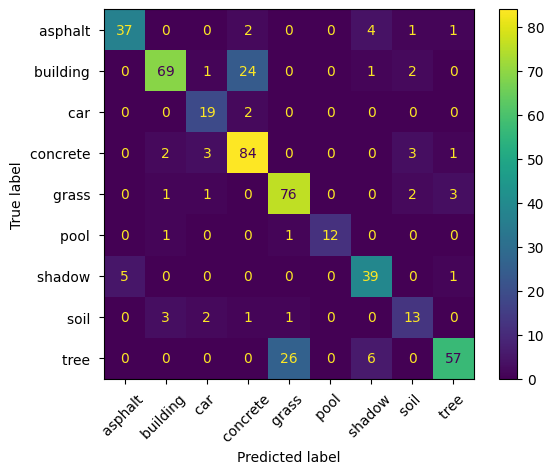

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
plt.figure(figsize=(10, 8))  # adjust as needed

disp.plot(xticks_rotation=45)
plt.show()